In [1]:
import os
import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Sequential
import torch.optim as optim
import voxelmorph as vxm
import neurite as ne
os.environ['VXM_BACKEND'] = 'pytorch'

backend:pytorch
Pytorch


In [2]:
os.environ.get('VXM_BACKEND')

'pytorch'

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [4]:
E1 = 1000
E2 = 1000

In [5]:
x_train = np.load('Train_3D_256_256_128_FOV_norm_data.npz')['Train']
x_train = np.transpose(x_train, (3, 0, 1, 2))
vol_shape = x_train.shape[1:]
print('train vol_shape:', vol_shape)
print('train shape:', x_train.shape)

train vol_shape: (128, 256, 256)
train shape: (59, 128, 256, 256)


In [6]:
import torch

def vxm_data_generator(x_data, batch_size):
    vol_shape = x_data.shape[1:]  # データ形状を取得
    ndims = len(vol_shape)
    
    zero_phi = np.zeros([batch_size, *vol_shape, ndims])
    
    while True:
        idx1 = np.random.randint(0, x_data.shape[0], size=batch_size)
        moving_images = x_data[idx1, ..., np.newaxis]
        idx2 = np.random.randint(0, x_data.shape[0], size=batch_size)
        fixed_images = x_data[idx2, ..., np.newaxis]

        # TensorFlowからPyTorchのデータ形式に変換
        moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
        fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()

        # チャンネルを最初の次元に追加
        moving_images = moving_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動
        fixed_images = fixed_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動

        inputs = [moving_images, fixed_images]
        outputs = [fixed_images, zero_phi]

        yield (inputs, outputs)

In [7]:
train_generator = vxm_data_generator(x_train, batch_size=2)
in_sample, out_sample = next(train_generator)

# in_sampleとout_sampleの内容を確認する
print("Input Sample Shapes:")
print("Moving Images Shape:", in_sample[0].shape)
print("Fixed Images Shape:", in_sample[1].shape)

print("\nOutput Sample Shapes:")
print("Moved Images (Fixed) Shape:", out_sample[0].shape)
print("Zero Gradient Shape:", out_sample[1].shape)

Input Sample Shapes:
Moving Images Shape: torch.Size([2, 1, 128, 256, 256])
Fixed Images Shape: torch.Size([2, 1, 128, 256, 256])

Output Sample Shapes:
Moved Images (Fixed) Shape: torch.Size([2, 1, 128, 256, 256])
Zero Gradient Shape: (2, 128, 256, 256, 3)


In [8]:
mse_loss = vxm.losses.MSE().loss
grad_loss = vxm.losses.Grad('l2').loss

def total_loss(y_true, y_pred):
    mse = mse_loss(y_true, y_pred)
    grad = grad_loss(y_true, y_pred)
    return mse + 0.01 * grad, mse, grad
#     return mse_loss(y_true, y_pred)

def MSE_Loss(y_true, y_pred):
    mse = mse_loss(y_true, y_pred)
    return mse

In [9]:
import torch
import torch.nn.functional as F

def gaussian_pyramid(img, num_levels=4):
    pyr = [img]
    for i in range(num_levels - 1):
        img = F.interpolate(img, scale_factor=0.5, mode='trilinear', align_corners=False)
        pyr.append(img)
    return pyr

def laplacian_pyramid(img, num_levels=4):
    pyr = gaussian_pyramid(img, num_levels)
    lap_pyr = []
    for i in range(num_levels - 1):
        up = F.interpolate(pyr[i + 1], size=pyr[i].shape[2:], mode='trilinear', align_corners=False)
        lap_pyr.append(pyr[i] - up)
    lap_pyr.append(pyr[-1])
    return lap_pyr

def laplacian_pyramid_loss(img1, img2, num_levels=4):
    pyr1 = laplacian_pyramid(img1, num_levels)
    pyr2 = laplacian_pyramid(img2, num_levels)
    
    loss = 0.0
    for l1, l2 in zip(pyr1, pyr2):
        loss += F.mse_loss(l1, l2)
    
    return loss

In [10]:
# configure unet input shape (concatenation of moving and fixed images)
ndim = 3
unet_input_features = 2
# inshape = (*x_train.shape[1:], unet_input_features)

nb_features = [
    [32, 64, 64, 64, 64],
    [64, 64, 64, 64, 64, 32, 16, 16]
]

In [11]:
model3D_3 = vxm.networks.VxmDense((128, 256, 256), nb_features, int_steps=0)
model3D_3.to(device)
optimizer = optim.Adam(model3D_3.parameters(), lr=1e-4)

5
6
7
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
[64, 128, 128]


C:\Users\user\anaconda3\envs\nn\lib\site-packages\torch\functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3550.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [12]:
# from tqdm.notebook import tqdm

# # パラメータ設定
# batch_size = 2
# channels = 3  # x軸, y軸, z軸
# depth, height, width = 64, 128, 128

# def smooth_field(field, kernel_size=5, sigma=2):
#     # ガウスカーネルの作成
#     coords = torch.arange(kernel_size) - kernel_size // 2
#     grid = torch.meshgrid(coords, coords, coords, indexing='ij')
#     kernel = torch.exp(-(grid[0]**2 + grid[1]**2 + grid[2]**2) / (2 * sigma**2))
#     kernel = kernel / kernel.sum()
#     kernel = kernel.to(field.device)

#     # カーネルの次元調整と複製
#     channels = field.shape[1]
#     kernel = kernel.expand(channels, 1, -1, -1, -1)  # [channels, 1, depth, height, width]

#     # 畳み込みで平滑化 (バッチ全体に適用)
#     field_smoothed = F.conv3d(field, kernel, padding=kernel_size // 2, groups=channels)
#     return field_smoothed

# # パラメータ設定
# batch_size = 2
# channels = 3  # x軸, y軸, z軸
# depth, height, width = 64, 128, 128
# random_range = (0, 10)

# # 乱数生成
# pos_flow = torch.rand((batch_size, channels, depth, height, width))  # [0, 1]の範囲
# pos_flow = pos_flow * (random_range[1] - random_range[0]) + random_range[0]  # [0, 5]の範囲

# # 平滑化
# pos_flow_smoothed = smooth_field(pos_flow)
# pos_flow = pos_flow_smoothed
# transformer = vxm.layers.SpatialTransformer((64, 128, 128)).to(device)

# epochs = 1000
# losses = []
# mses = []
# grads = []
# laplacian_losses = []
# total_loss_values = []

# for epoch in tqdm(range(epochs)):
    
#     # 学習データのバッチを取得
#     train_batch,_ = next(train_generator)
#     moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
    
#     moving_images = torch.nn.functional.interpolate(moving_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
    
#     # 乱数生成
#     # pos_flow = torch.rand((batch_size, channels, depth, height, width))  # [0, 1]の範囲
#     # pos_flow = pos_flow * (random_range[1] - random_range[0]) + random_range[0]  # [0, 5]の範囲
    
#     pos_flow = pos_flow.to(device)
#     moving_images = moving_images.to(device)
    
#     # pos_flow_smoothed = smooth_field(pos_flow)
#     moving_images2 = transformer(moving_images, pos_flow)
    
    
#   # 勾配を初期化
#     optimizer.zero_grad()

#     # 順伝播
#     transformed_image, Vec = model3D_3(moving_images, moving_images2)

#     loss = MSE_Loss(pos_flow, Vec)
    
#     # 逆伝播
#     loss.backward()
#     optimizer.step()

#     torch.save(model3D_3.state_dict(), 'model_VXM_3D_weights_Rand.pth')

        
#     # エポックごとのロスを保存
    
#     losses.append(loss.cpu().item())
       

#     # エポックごとのロスの表示
# #     print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_all:.4f}")
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

In [13]:
# import torch
# import numpy as np
# import matplotlib.pyplot as plt

# # 損失、MSE、勾配をプロット
# epochs_range = range(1, epochs + 1)

# plt.figure(figsize=(12, 8))
# plt.plot(epochs_range, losses, label='Loss')

# plt.xlabel('Epochs')
# plt.ylabel('Value')
# plt.title('Training Metrics')
# plt.legend()
# plt.show()

In [14]:
from tqdm.notebook import tqdm
transformer = vxm.layers.SpatialTransformer((128, 256, 256)).to(device)

# エポック数とアーリーストッピングの設定
epochs = 10000
patience = 500  # ロス改善が見られないエポック数でアクション
min_delta = 0.02  # ロス改善の最小差
best_loss = float('inf')
no_improve_epochs = 0

# ロスや他のメトリクスを記録するリスト
losses = []
shift_range = 3  # 初期位置ずれ範囲

for epoch in tqdm(range(epochs)):
    # 学習データのバッチを取得
    train_batch, _ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32)

    # 入力データのリサイズ（64x128x128に統一）
    # moving_images = torch.nn.functional.interpolate(moving_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
    moving_images = moving_images.to(device)

    # 位置ずれを生成する
    shift_x = torch.randint(-shift_range, shift_range + 1, (1,)).item()
    shift_y = torch.randint(-shift_range, shift_range + 1, (1,)).item()
    shift_z = torch.randint(-shift_range, shift_range + 1, (1,)).item()

    # 位置ずれフィールドを作成
    displacement_field = torch.zeros((moving_images.size(0), 3, *moving_images.shape[2:]), dtype=torch.float32).to(device)
    displacement_field[:, 0, :, :, :] += shift_x  # x方向のシフト
    displacement_field[:, 1, :, :, :] += shift_y  # y方向のシフト
    displacement_field[:, 2, :, :, :] += shift_z  # z方向のシフト

    # 位置をずらした画像を生成
    moving_images2 = transformer(moving_images, displacement_field)

    # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
    transformed_image, Vec = model3D_3(moving_images, moving_images2)

    # 損失を計算
    loss = MSE_Loss(moving_images2, transformed_image)

    # 逆伝播
    loss.backward()
    optimizer.step()

    # エポックごとのロスを保存
    losses.append(loss.cpu().item())

    # ベストロスの更新とアーリーストッピングの判断
    if loss < best_loss - min_delta:
        best_loss = loss
        no_improve_epochs = 0
    else:
        no_improve_epochs += 1

    # ロスが改善しない場合の処理
    if no_improve_epochs >= patience:
        if shift_range < 10:  # 位置ずれの範囲を広げる
            shift_range += 1
            print(f"Loss stagnated for {patience} epochs. Increasing shift range to ±{shift_range} pixels.")
            no_improve_epochs = 0  # 再度改善の監視を開始
        else:
            print(f"Loss did not improve for {patience} epochs and shift range is max. Stopping early at epoch {epoch+1}.")
            break  # 学習を停止

    # エポックごとのロスの表示
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, Shift Range: ±{shift_range} pixels")

  0%|          | 0/10000 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Temp\ipykernel_10336\2172788133.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  moving_images = torch.tensor(train_batch[0], dtype=torch.float32)


torch.Size([2, 3, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])
Epoch 1/10000, Loss: 0.0082, Shift Range: ±3 pixels
torch.Size([2, 3, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])
Epoch 2/10000, Loss: 0.0061, Shift Range: ±3 pixels
torch.Size([2, 3, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])
Epoch 3/10000, Loss: 0.0043, Shift Range: ±3 pixels
torch.Size([2, 3, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])
Epoch 4/10000, Loss: 0.0060, Shift Range: ±3 pixels
torch.Size([2, 3, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])
Epoch 5/10000, Loss: 0.0053, Shift Range: ±3 pixels
torch.Size([2, 3, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])
Epoch 6/10000, Loss: 0.0051, Shift Range: ±3 pixels
torch.Size([2, 3, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])
Epoch 7/10000, Loss: 0.0041, Shift Range: ±3 pixels
torch.Size([2, 3, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])
Epoch 8/10000, Loss: 0.0068, Shift Range: ±3 pixels
torch.Size([2, 3, 128, 256, 256])
torch.

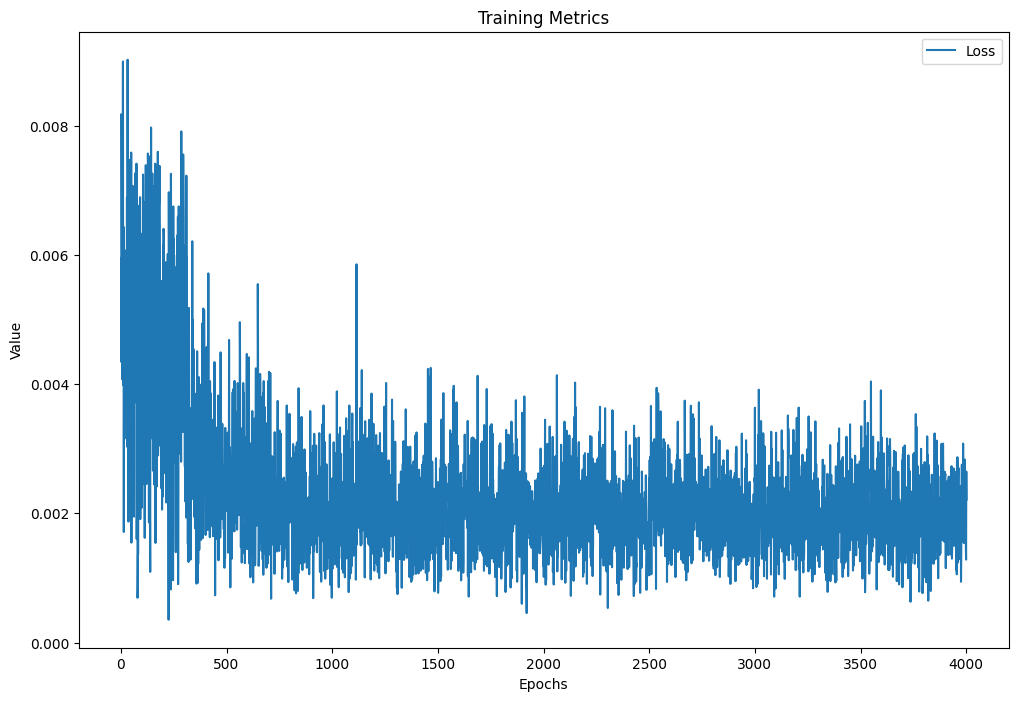

In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 損失、MSE、勾配をプロット
epochs_range = range(1,  epoch+2)

plt.figure(figsize=(12, 8))
plt.plot(epochs_range, losses, label='Loss')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Training Metrics')
plt.legend()
plt.show()

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# model3D_7 = vxm.networks.VxmDense((64, 128, 128), nb_features, int_steps=0)
# model3D_7.to(device)
# optimizer = optim.Adam(model3D_7.parameters(), lr=1e-4)

# 学習済みモデルが既にある場合
# model3D_7.load_state_dict(torch.load('model_VXM_3D_weights_laplacian_omomi_hukaku.pth', map_location=device))
# model3D_7.load_state_dict(torch.load('model_VXM_3D_weights_Adam1.pth', map_location=device))
CT1 = np.load('No6_CT1_256_256_128.npz')['Train']
CT1 = np.transpose(CT1, (3, 0, 1, 2))
print('CT1_shape:', CT1.shape)
CT2 = np.load('No6_CT2_256_256_128.npz')['Train']
CT2 = np.transpose(CT2, (3, 0, 1, 2))
print('CT2_shape:', CT2.shape)

x_val_1 = CT1[0, :, :, :]
x_val_1 = x_val_1[np.newaxis, ..., np.newaxis]
x_val_2 = CT2[0, :, :, :]
x_val_2 = x_val_2[np.newaxis, ..., np.newaxis]

batch_size = 2

idx1 = np.random.randint(0, x_val_1.shape[0], size=batch_size)
moving_images = x_val_1[idx1]
moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
moving_images11 = moving_images.permute(0, 1, 2, 3, 4)
print(moving_images11.shape)

idx2 = np.random.randint(0, x_val_2.shape[0], size=batch_size)
fixed_images = x_val_2[idx2]
fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()
fixed_images11 = fixed_images.permute(0, 1, 2, 3, 4)
print(fixed_images11.shape)

# 検証データを使って予測を行う
model3D_7 = model3D_3
model3D_7.eval()  # モデルを評価モードにする
with torch.no_grad():  # 勾配計算を無効化

    moving_images = fixed_images11
    fixed_images = moving_images11

    moving_images = torch.nn.functional.interpolate(moving_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
    
    moving_images = moving_images.to(device)

    moving_images2 = transformer(moving_images, displacement_field)
    
    transformed_image, pos_flow= model3D_7(moving_images, moving_images2)

    
# バッチから最初の画像を取得
moving_image = moving_images[0].cpu().numpy()
fixed_image = moving_images2[0].cpu().numpy()
transformed_image = transformed_image[0].cpu().numpy()
vector_field11 = pos_flow[0].cpu().numpy()

CT1_shape: (1, 128, 256, 256)
CT2_shape: (1, 128, 256, 256)
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])


RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 64 but got size 128 for tensor number 1 in the list.

In [ ]:
import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 32

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, i, :, :]
plt.imshow(A, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, i, :, :]
plt.imshow(B, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, i, :, :]
plt.imshow(C, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

In [ ]:
# from tqdm.notebook import tqdm

# epochs = 1000
# losses = []
# mses = []
# grads = []
# laplacian_losses = []
# total_loss_values = []

# for epoch in tqdm(range(epochs)):
    
#     # 学習データのバッチを取得
#     train_batch,_ = next(train_generator)
#     moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
    
#     moving_images = torch.nn.functional.interpolate(moving_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
    
#     moving_images = moving_images.to(device)
    
#     # pos_flow_smoothed = smooth_field(pos_flow)
#     moving_images2 = transformer(moving_images, pos_flow)
    
    
#   # 勾配を初期化
#     optimizer.zero_grad()

#     # 順伝播
#     transformed_image, Vec = model3D_3(moving_images, moving_images2)

#     loss = MSE_Loss(pos_flow, Vec)
    
#     # 逆伝播
#     loss.backward()
#     optimizer.step()

#     torch.save(model3D_3.state_dict(), 'model_VXM_3D_weights_Rand.pth')

        
#     # エポックごとのロスを保存
    
#     losses.append(loss.cpu().item())
       

#     # エポックごとのロスの表示
# #     print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_all:.4f}")
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# model3D_7 = vxm.networks.VxmDense((64, 128, 128), nb_features, int_steps=0)
# model3D_7.to(device)
# optimizer = optim.Adam(model3D_7.parameters(), lr=1e-4)

# # 学習済みモデルが既にある場合
# model3D_7.load_state_dict(torch.load('model_VXM_3D_weights_laplacian_omomi_hukaku.pth', map_location=device))
# model3D_7.load_state_dict(torch.load('model_VXM_3D_weights_Adam1.pth', map_location=device))
CT1 = np.load('No6_CT1_256_256_128.npz')['Train']
CT1 = np.transpose(CT1, (3, 0, 1, 2))
print('CT1_shape:', CT1.shape)
CT2 = np.load('No6_CT2_256_256_128.npz')['Train']
CT2 = np.transpose(CT2, (3, 0, 1, 2))
print('CT2_shape:', CT2.shape)

x_val_1 = CT1[0, :, :, :]
x_val_1 = x_val_1[np.newaxis, ..., np.newaxis]
x_val_2 = CT2[0, :, :, :]
x_val_2 = x_val_2[np.newaxis, ..., np.newaxis]

batch_size = 2

idx1 = np.random.randint(0, x_val_1.shape[0], size=batch_size)
moving_images = x_val_1[idx1]
moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
moving_images11 = moving_images.permute(0, 1, 2, 3, 4)
print(moving_images11.shape)

idx2 = np.random.randint(0, x_val_2.shape[0], size=batch_size)
fixed_images = x_val_2[idx2]
fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()
fixed_images11 = fixed_images.permute(0, 1, 2, 3, 4)
print(fixed_images11.shape)

# 検証データを使って予測を行う
model3D_7.eval()  # モデルを評価モードにする
with torch.no_grad():  # 勾配計算を無効化

    moving_images = fixed_images11
    fixed_images = moving_images11

    # moving_images = torch.nn.functional.interpolate(moving_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
    # fixed_images = torch.nn.functional.interpolate(fixed_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    transformed_image, pos_flow= model3D_7(moving_images, fixed_images)

    
# バッチから最初の画像を取得
moving_image = moving_images[0].cpu().numpy()
fixed_image = fixed_images[0].cpu().numpy()
transformed_image = transformed_image[0].cpu().numpy()
vector_field11 = pos_flow[0].cpu().numpy()

CT1_shape: (1, 128, 256, 256)
CT2_shape: (1, 128, 256, 256)
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 3, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])


In [1]:
import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 64

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, i, :, :]
plt.imshow(A, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, i, :, :]
plt.imshow(B, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, i, :, :]
plt.imshow(C, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [ ]:
import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 32

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, i, :, :]
plt.imshow(A, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, i, :, :]
plt.imshow(B, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, i, :, :]
plt.imshow(C, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

In [ ]:
imsave('moving_image4.tiff', A)
imsave('fixed_image4.tiff', B)
imsave('moved_image411.tiff', C)